In [95]:
#Leo Murch
#AST4762
#Fall 2026
#Practicum 3

In [96]:
import numpy as np
import matplotlib.pyplot as plt

In [97]:
print('Problem 1')
#a)

Problem 1


In [98]:
#need to read the dat file
#each one is seperated by two pound signs before the data

mod_1 = [[],[]]
mod_2 = [[],[]]
current_mod = None
with open("practicum3_1.dat") as f: #cant use loadtxt since there's 2 diff files
    for line in f:
        line = line.strip() #just in case, i do it regardless
        if line.startswith("#Model 1"): #this might be crude but i think its alright?
            #if its bad coding practice, pls let me know
            current_mod = 1
        elif line.startswith("#Model 2"):
            current_mod = 2

        elif line.startswith("#") or line == "": #for the comments of which to use
            # had to look up the or line = "" part, apparently split still leaves those with space delimits.
            continue

        #all of these has have to be the data
        else:
            contents = line.split() #splits into two spaces of x and y
            i = float(contents[0]) #was putting in strings before and messing up plotting
            j = float(contents[1])
    
            if current_mod == 1:
                mod_1[0].append(i)
                mod_1[1].append(j)
            elif current_mod == 2:
                mod_2[0].append(i)
                mod_2[1].append(j)
f.close()

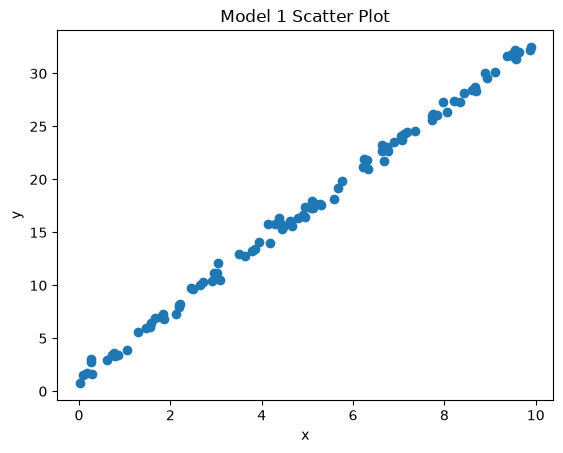

In [99]:
#now make them both nice arrays:
mod_1 = np.array(mod_1)
mod_2 = np.array(mod_2)

#plotting:
plt.scatter(mod_1[0], mod_1[1])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Model 1 Scatter Plot")
#wow i got some really really ugly tick marks
#it was because they were plotting the string values, i went back and casted i,j to float()
plt.show()
#all better

In [100]:
#b)
import linfit as L  #stole it from the demos in week 5
#like the demo:
ret_p5 = L.linfit(mod_1[1], mod_1[0], 0.5) #y first is kinda annoying when a lotta stuff is x first
#do uncertainty of 0.5 as specified as well.
ret_p2 = L.linfit(mod_1[1], mod_1[0], 0.2)
ret_p9 = L.linfit(mod_1[1], mod_1[0], 0.9)
#guess we didnt need to actually call them, just comment on the fit

#indices of the tuple are:
#[0] intercept (a), 
#[1] slope (b), 
#[2] 1sig uncertainty for a,
#[3] b, 
#[4] chi square, 
#[5] probability of getting worse chi_sq, 
#[6] covariance matrix (a,b),
#[7] best fit line

#the specified sigma values matter since they impact the uncertainties and chi_sq value
#smaller given error nets in smaller 1sigma uncertainties for a,b, and vice versa.
#chi_sq follows off of a 1/sigma. Smaller error makes a larger chi_sq for the same fit (overshooting sigma we talked abt in class)

#to test if they fall within the 3 sigma, compare what the s_a,b look like for the fitted a,b, minus the models:
# 3sig check vs true a=1.2, b=3.2
print("Comparing fitted intercept to 3sigma:", ret_p5[0] - 1.2, 3 * ret_p5[2])
print("smaller than 0.299, def within 3sig")
print("\nFor the slope:")
print("diff of |b_fit - 3.2| = ", 3.2 - ret_p5[1], "3_sig_b = ", ret_p5[3])
print("Closer, but still within 3 sigma")

Comparing fitted intercept to 3sigma: 0.0996258201061393 0.2994692017893014
smaller than 0.299, def within 3sig

For the slope:
diff of |b_fit - 3.2| =  0.015141610475110312 3_sig_b =  0.01751217645710987
Closer, but still within 3 sigma



Probability of higher chi_sq is:  0.8439045061329364


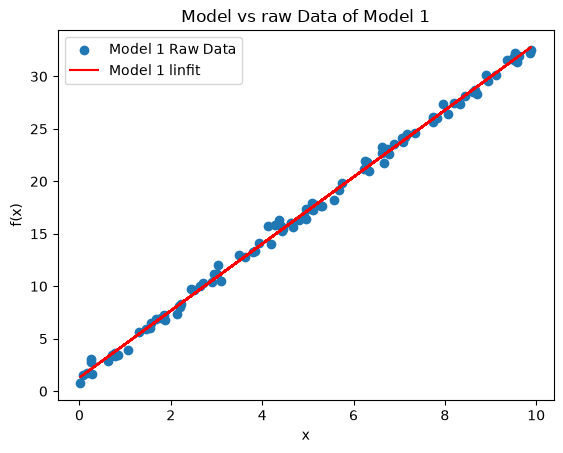

In [101]:
#c)
#probability is already given within the linfit,
print("\nProbability of higher chi_sq is: ", ret_p5[5])

#plotting:
a = ret_p5[0]
b = ret_p5[1]
plt.scatter(mod_1[0], mod_1[1], label = "Model 1 Raw Data")
plt.plot(mod_1[0], a + mod_1[0]*b, color = 'red', label = 'Model 1 linfit')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.title("Model vs raw Data of Model 1")
plt.savefig("p3_aleonav_problem1_graph1.png") # save

Comparing fitted intercept to 3sigma: 51.76012277867994 0.2994692017893014
DEFINITELY not within 3 sigma at all.

For the slope:
diff of |b_fit - 3.2| =  28.371365649326474 3_sig_b =  0.01751217645710987
DEFINITELY not within 3 sigma as well.

Probability of higher chi_sq is:  0.0
Chi_sq of model 2 is:  240064.44240123458
Chi_sq of model 1 is:  83.91362840307836
# of points in the arrays are:  100


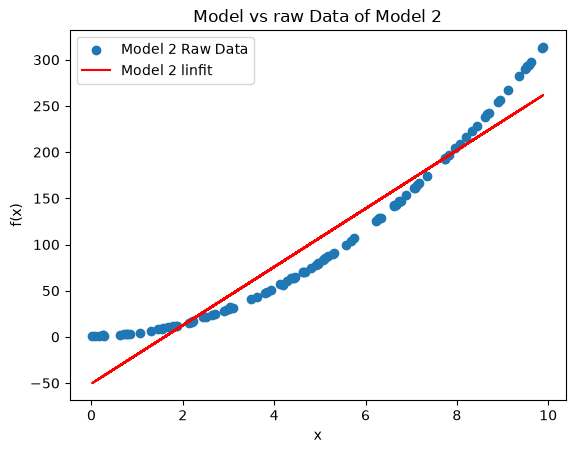

In [102]:
#d)
#now call for model 2, go thru the steps to do the same:
ret2 = L.linfit(mod_2[1], mod_2[0], 0.5)
print("Comparing fitted intercept to 3sigma:", 1.2 - ret2[0], 3 * ret2[2])
print("DEFINITELY not within 3 sigma at all.")
print("\nFor the slope:")
print("diff of |b_fit - 3.2| = ", ret2[1] - 3.2, "3_sig_b = ", ret2[3])
print("DEFINITELY not within 3 sigma as well.")

#ill copy paste part c and change the data being taken in:
#probability is already given within the linfit,
print("\nProbability of higher chi_sq is: ", ret2[5])

#plotting:
a = ret2[0]
b = ret2[1]
plt.scatter(mod_2[0], mod_2[1], label = "Model 2 Raw Data")
plt.plot(mod_2[0], a + mod_2[0]*b, color = 'red', label = 'Model 2 linfit')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.title("Model vs raw Data of Model 2")
plt.savefig("p3_aleonav_problem1_graph2.png") # save to png



#ANSWERS FOR PART D
#def not a good fit of the data.
#it does all it can, but the differences are just too much, probability is even 0 on getting a higher one.

#two good reasons on why it cant fit the data could be:
#1) 
#the residuals of the model to the actual data is much larger than the assumed sigma of 0.5. Chi_sq ends up being prob massive lets see
print("Chi_sq of model 2 is: ", ret2[4]) #lmfao 240k
#lets compare with the 1st:
print("Chi_sq of model 1 is: ",ret_p5[4])
#lets see how many points there are:
print("# of points in the arrays are: ", np.size(mod_1[0]))
#100 points - 2 DOF is 98 for a good fit, so this is actually rlly good, better than 200k

#2)
#the base model it's trying to fit is wrong in the first place
#linfit is a linear fit, assuming a linear regression (im pretty sure) and nothing with fitting a square term in there.


In [103]:
print("Problem 2")
#a)
#use np.random.poisson, random.uniform, and then assempble htem togelther.
fish = np.random.poisson(10000, size = 396) #fish
unif = np.random.uniform(0, 1e6, size = 4) #importantly, not a fish (bad)

sample = np.concatenate([fish, unif]) #size 400 with the last 4 messed up

#mean and median of the sample:
print("Mean, Median of the sample is: ", np.mean(sample), np.median(sample))
#Median is def closer to N, at ~10000 while mean is like ~14500

Problem 2
Mean, Median of the sample is:  12542.948527370432 10010.0


In [104]:
#b) calc da stdev
sample_std = np.std(sample)
print("\nSample stdev: ", sample_std, "\n")

#do the masking of the data, from the L04 file:
clipped = sample[np.where(np.abs(sample - np.median(sample)) < 5 * sample_std)] #clip where the sample is outside 5sigma
print("New samples data:\
\nMean: ", np.mean(clipped),
"\nMedian: ", np.median(clipped),
"\nStdev: ", np.std(clipped))

#now the mean and median line up to be much closer to each other, as well as the std going down signifigantly.
#Before there were very large outliers at the tail end up the data pulling the mean way higher (+ ~4500) from the median
#(which should be pretty closer to the median w/out outliers, since it follows a poisson dist.)


Sample stdev:  31069.969773734414 

New samples data:
Mean:  10467.101773224846 
Median:  10009.0 
Stdev:  6686.114957935776
